# Laborator 5 - Rezolvarea unor probleme de regresie prin metode de învățare automată

💡 Probleme

Ce îi poate face pe oameni fericiți? Se consideră problema predicției gradului de fericire a populației globului folosind informații despre diferite caracteristici a bunăstării respectivei populații precum Produsul intern brut al țării în care locuiesc (gross domestic product – GBP), gradul de fericire, etc.

Folsind datele aferente anului 2017 (fisierul v1_world-happiness-report-2017.csv), să se realizeze o predicție a gradului de fericire în funcție:

* doar de Produsul intern brut (exemplu detaliat live - demo)
* doar de caracteristica "Family" (tema)
* de Produsul intern brut si de gradul de libertate (temă).

Rezolvati problema si pentru cazurile in care datele sunt preluate din fisierul:

* v2_world-happiness-report-2017.csv
* v3_world-happiness-report-2017.csv

#### Cerinte

Specificaţi, proiectaţi, implementaţi si testati un algoritm de predicție bazat pe metoda celor mai mici pătrate.

🏵️ Cerinte opționale

Studiul comportamentului algoritmului de predictie pentru date corelate sau incomplete.

#### Folosind datele aferente anului 2017 (fisierul v1_world-happiness-report-2017.csv), să se realizeze o predicție a gradului de fericire în funcție doar de Produsul intern brut

In [ ]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model, metrics

In [ ]:
# Standard normalization: (value - mean) / standard deviation
def standardNormalize(data):
    mean = np.mean(data)
    std_dev = np.std(data)
    normalizedData = (data - mean) / std_dev
    return normalizedData

**THEORY**

In order to handle missing values in the dataset, we replaced them with the mean of the available values for the corresponding variable. This approach, known as mean imputation, is commonly used in data preprocessing to avoid the removal of entire rows with incomplete data. It helps maintain the dataset size and ensures that the regression model can be trained without errors, as most machine learning algorithms require complete input data. Although it may introduce some bias, it is a simple and effective method when the percentage of missing data is low.

In [ ]:
# load data from a CSV file
def loadData(fileName, outputVariabName, inputVariabName1, inputVariabName2 = None):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row  # store the header
            else:
                data.append(row)  # store the data rows
            line_count += 1

    # extract and normalize output variable
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(row[selectedOutput]) for row in data]
    outputs = standardNormalize(outputs)

    # extract and normalize first input variable
    selectedVariable1 = dataNames.index(inputVariabName1)
    inputs1 = [float(row[selectedVariable1]) if row[selectedVariable1] != '' else None for row in data]

    # replace missing values with the mean
    mean_value1 = sum([val for val in inputs1 if val is not None]) / len([val for val in inputs1 if val is not None])
    for i in range(len(inputs1)):
        if inputs1[i] is None:
            inputs1[i] = mean_value1
    inputs1 = standardNormalize(inputs1)

    inputs2 = []

    # if second input variable is given
    if inputVariabName2 != None:
        selectedVariable2 = dataNames.index(inputVariabName2)
        inputs2 = [float(row[selectedVariable2]) if row[selectedVariable2] != '' else None for row in data]

        # replace missing values with the mean
        mean_value2 = sum([val for val in inputs2 if val is not None]) / len([val for val in inputs2 if val is not None])
        for i in range(len(inputs2)):
            if inputs2[i] is None:
                inputs2[i] = mean_value2
        inputs2 = standardNormalize(inputs2)

    # return data: either (outputs, input1) or (outputs, input1, input2)
    if not len(inputs2):
        return outputs, inputs1
    else:
        return outputs, inputs1, inputs2

In [ ]:
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

In [ ]:
# plot training data, model line, and optionally test data
def plotData(x1, y1, x2 = None, y2 = None, x3 = None, y3 = None, title = None):
    plt.plot(x1, y1, 'ro', label = 'train data')  # red circles
    if (x2):
        plt.plot(x2, y2, 'b-', label = 'learnt model')  # blue line
    if (x3):
        plt.plot(x3, y3, 'g^', label = 'test data')  # green triangles
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
# split data into training (80%) and testing (20%)
def splitData(inputs, outputs):
    np.random.seed(5)  # fixed seed for reproducibility = to obtain the same data every time
    indexes = [i for i in range(len(inputs))]

    # randomly select 80% of the data for training
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)

    # remaining 20% will be used for validation/testing
    validationSample = [i for i in indexes  if not i in trainSample]

    # extract the actual data based on the indices
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    validationInputs = [inputs[i] for i in validationSample]
    validationOutputs = [outputs[i] for i in validationSample]

    return trainInputs, trainOutputs, validationInputs, validationOutputs

In [ ]:
# plot the learned linear model along with the training data
def plotModel(trainInputs, trainOutputs, w0, w1):
    noOfPoints = 1000  # number of reference points for plotting the model line

    # generate evenly spaced x values between min and max of training data
    xref = []
    val = min(trainInputs)
    step = (max(trainInputs) - min(trainInputs)) / noOfPoints
    for i in range(1, noOfPoints):
        xref.append(val)
        val += step

    # calculate the corresponding y values using the linear model
    yref = [w0 + w1 * el for el in xref]

    plotData(trainInputs, trainOutputs, xref, yref, [], [], title = "train data and model")

 **THEORY**

Measuring Prediction Error (Mean Squared Error)
To evaluate how well a regression model performs, we need to compare the predicted outputs with the actual outputs. A common way to do this is by calculating the Mean Squared Error (MSE). This metric represents the average of the squared differences between the predicted values and the actual (real) values.

The computeError function calculates MSE in two ways:

Manually, by iterating over the predictions and actual values, computing the squared difference for each pair, and taking the average.

Using a built-in tool (sklearn.metrics.mean_squared_error), which ensures correctness and saves time in larger applications.

MSE is widely used because it penalizes larger errors more than smaller ones, making it a good indicator of the model's accuracy. A lower MSE means the predictions are closer to the real values, indicating a better model.

In [ ]:
def computeError(validationOutputs, computedValidationOutputs):
    error = 0.0
    # manually compute mean squared error
    for t1, t2 in zip(computedValidationOutputs, validationOutputs):
        error += (t1 - t2) ** 2
    error = error / len(validationOutputs)
    print("prediction error (manual): ", error)

    # compute error using sklearn's built-in function
    error = metrics.mean_squared_error(validationOutputs, computedValidationOutputs)
    print("prediction error (tool): ", error)

In [ ]:
def makePrediction(filePath, inputVariable, outputVariable):
    outputs, inputs = loadData(filePath, outputVariable, inputVariable, inputVariabName2=None)

    # visualize input and output distributions
    plotDataHistogram(inputs, inputVariable)
    plotDataHistogram(outputs, outputVariable)

    # check if there's a linear relationship between input and output
    plotData(inputs, outputs, [], [], [], [], inputVariable + " vs. " + outputVariable)

    # split the data into 80% training and 20% testing (validation)
    trainInputs, trainOutputs, validationInputs, validationOutputs = splitData(inputs, outputs)
    plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

    # training step using sklearn LinearRegression
    xx = [[el] for el in trainInputs]  # reshape inputs to 2D array as required by sklearn
    regressor = linear_model.LinearRegression()
    # alternative: regressor = linear_model.SGDRegressor(max_iter=10000)
    regressor.fit(xx, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_  # extract model parameters

    # plot the learned model along with training data
    plotModel(trainInputs, trainOutputs, w0, w1)

    # use the model to make predictions on validation data
    computedValidationOutputs = regressor.predict([[x] for x in validationInputs])

    # plot real vs. predicted outputs
    plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data')  # yellow circles
    plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')  # green triangles
    plt.title('computed validation and real validation data')
    plt.xlabel('GDP capita')
    plt.ylabel('happiness')
    plt.legend()
    plt.show()

    # compute prediction errors (manual and with tool)
    computeError(validationOutputs, computedValidationOutputs)

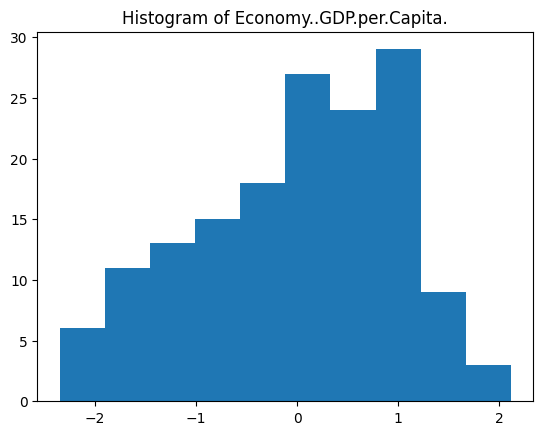

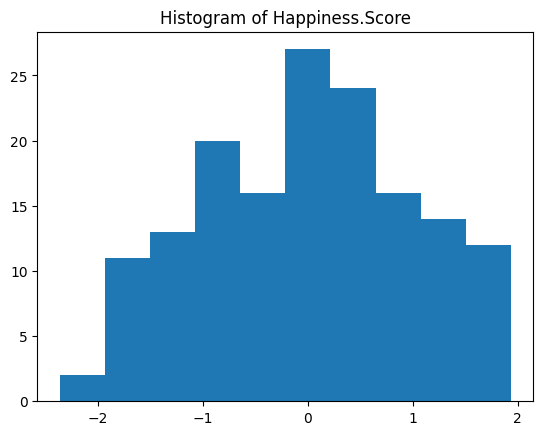

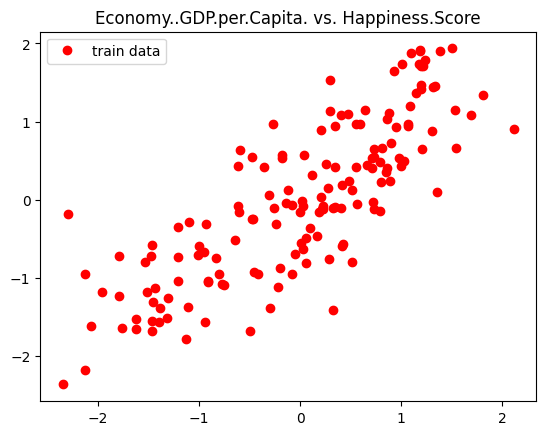

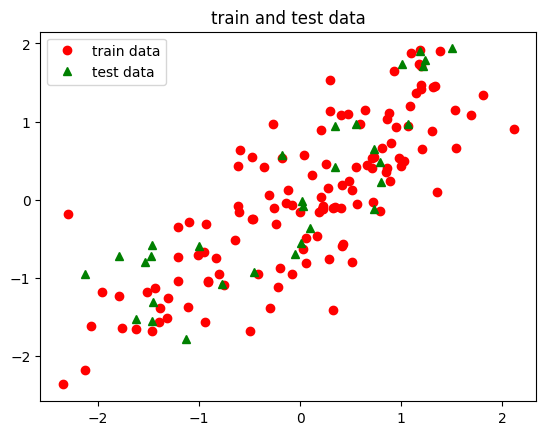

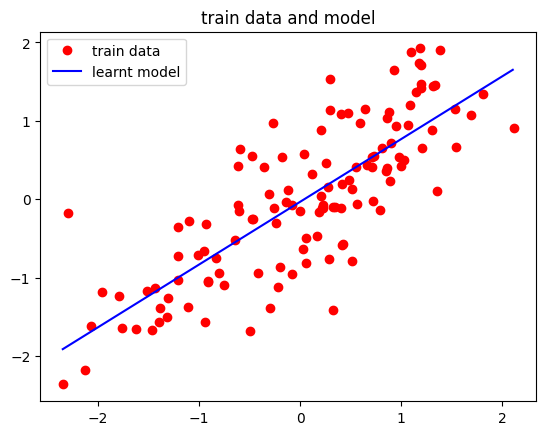

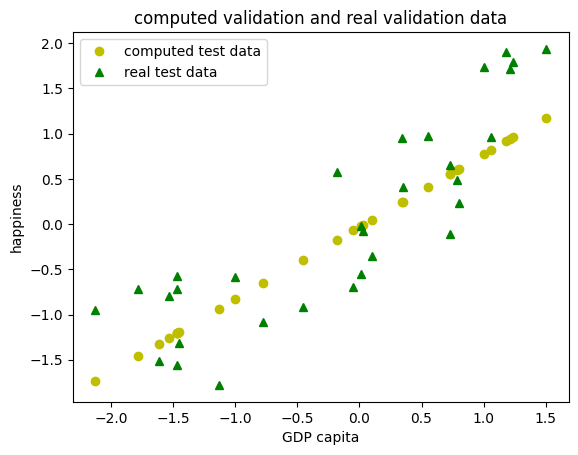

prediction error (manual):  0.32578553890299705
prediction error (tool):  0.325785538902997


In [ ]:
filePath = "/content/v1_world-happiness-report-2017.csv"

inputVariable = 'Economy..GDP.per.Capita.'
outputVariable = 'Happiness.Score'

makePrediction(filePath, inputVariable, outputVariable)

#### Folosind datele aferente anului 2017 (fisierul v1_world-happiness-report-2017.csv), să se realizeze o predicție a gradului de fericire în funcție doar de caracteristica "Family"

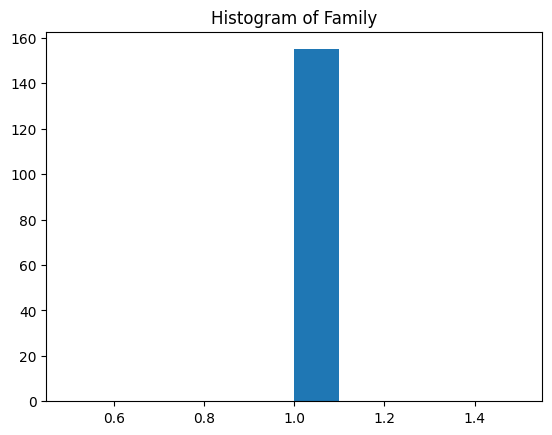

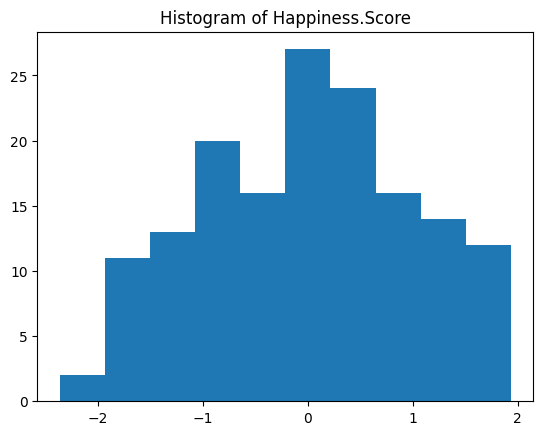

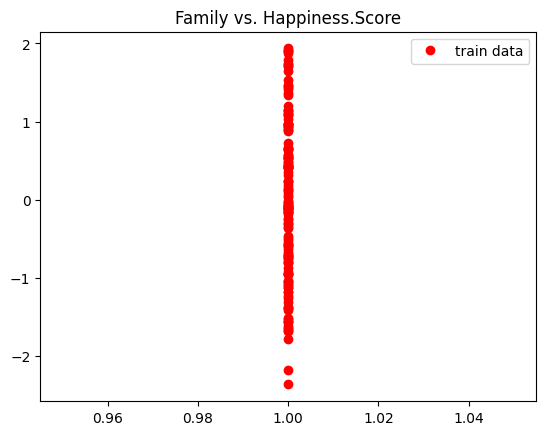

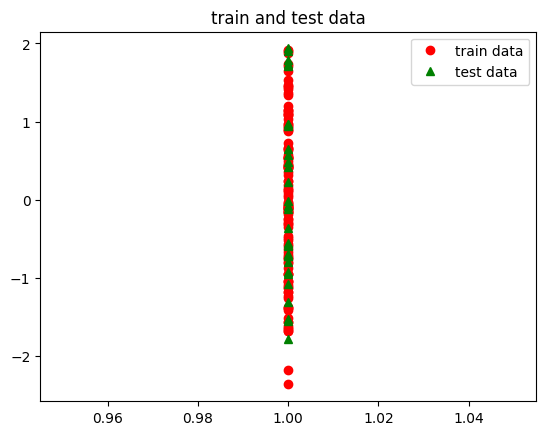

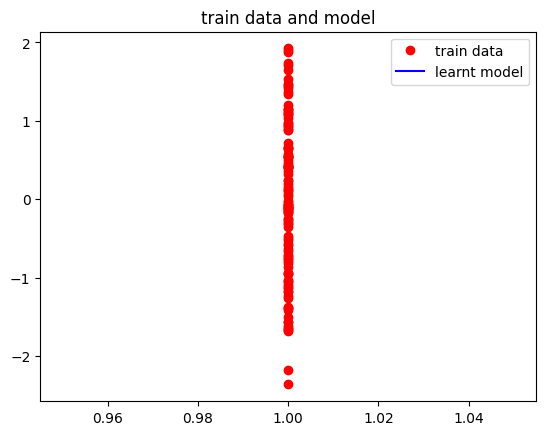

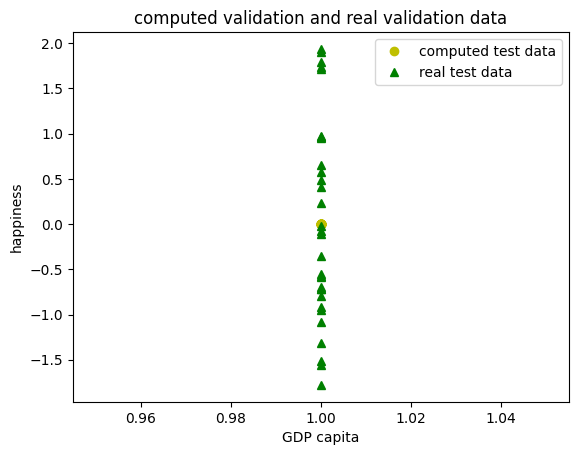

prediction error (manual):  1.1711027958450777
prediction error (tool):  1.1711027958450777


In [ ]:
filePath = "/content/v1_world-happiness-report-2017.csv"

inputVariable = 'Family'
outputVariable = 'Happiness.Score'

makePrediction(filePath, inputVariable, outputVariable)

#### Folosind datele aferente anului 2017 (fisierul v1_world-happiness-report-2017.csv), să se realizeze o predicție a gradului de fericire în funcție de Produsul intern brut si de gradul de libertate

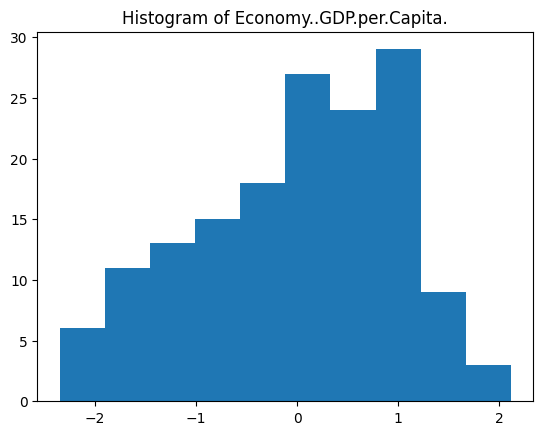

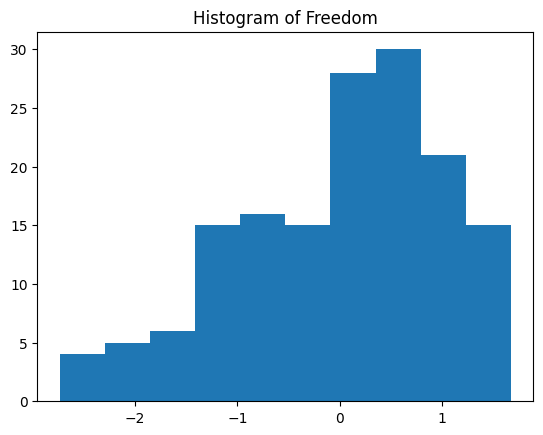

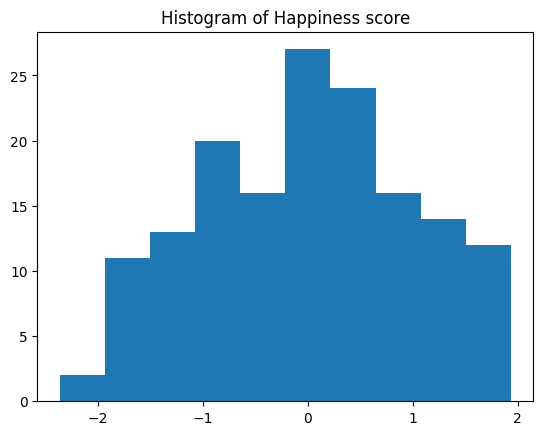

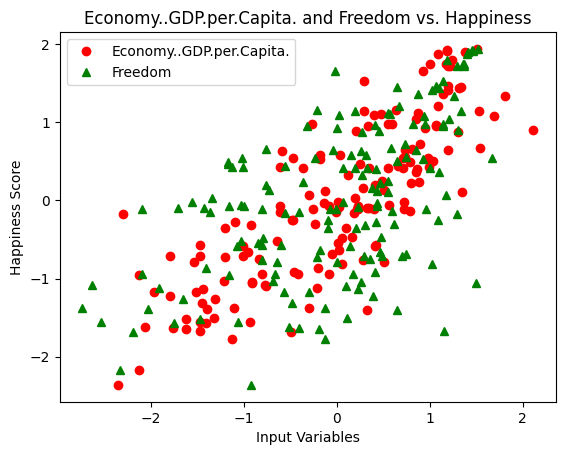

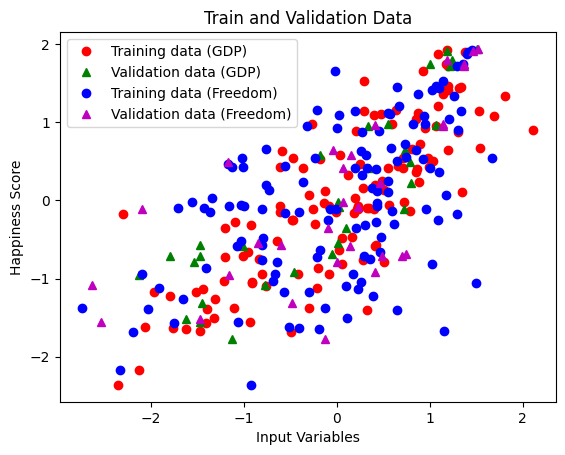

The learnt model: f(x1, x2) =  -0.02815893592597309  +  0.6979567354263436  * x1 +  0.3069278912329719  * x2


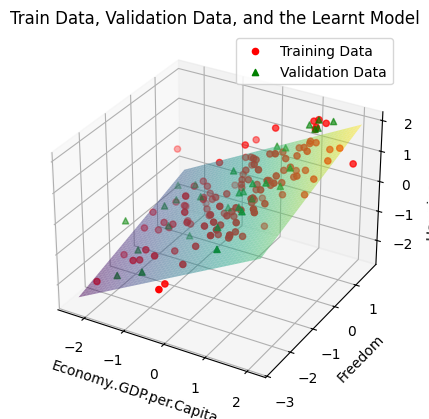

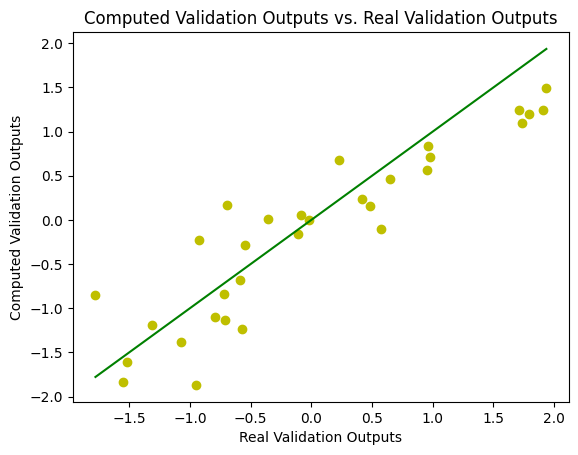

prediction error (manual):  0.2185159430674899
prediction error (tool):  0.21851594306748995


In [ ]:
filePath = "/content/v1_world-happiness-report-2017.csv"

inputVariable1 = 'Economy..GDP.per.Capita.'
inputVariable2 = 'Freedom'
outputVariable = 'Happiness.Score'

outputs, inputs1, inputs2 = loadData(filePath, outputVariable, inputVariable1, inputVariable2)

plotDataHistogram(inputs1, 'Economy..GDP.per.Capita.')
plotDataHistogram(inputs2, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

# check the liniarity

plt.plot(inputs1, outputs, 'ro', label='Economy..GDP.per.Capita.')
plt.plot(inputs2, outputs, 'g^', label='Freedom')
plt.xlabel('Input Variables')
plt.ylabel('Happiness Score')
plt.title('Economy..GDP.per.Capita. and Freedom vs. Happiness')
plt.legend()
plt.show()

# combine inputs into one matrix
X = np.column_stack((inputs1, inputs2))

# split data into training data (80%) and testing data (20%)
np.random.seed(5)
indexes = np.arange(len(inputs1))

trainSample = np.random.choice(indexes, int(0.8 * len(inputs1)), replace=False)
validationSample = np.array([i for i in indexes if i not in trainSample])

trainInputs = X[trainSample]
trainOutputs = np.array([outputs[i] for i in trainSample])

validationInputs = X[validationSample]
validationOutputs = np.array([outputs[i] for i in validationSample])

# plot train and validation data
plt.plot(trainInputs[:,0], trainOutputs, 'ro', label='Training data (GDP)')
plt.plot(validationInputs[:,0], validationOutputs, 'g^', label='Validation data (GDP)')
plt.plot(trainInputs[:,1], trainOutputs, 'bo', label='Training data (Freedom)')
plt.plot(validationInputs[:,1], validationOutputs, 'm^', label='Validation data (Freedom)')
plt.title('Train and Validation Data')
plt.xlabel('Input Variables')
plt.ylabel('Happiness Score')
plt.legend()
plt.show()

# training step
regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
print('The learnt model: f(x1, x2) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2')

# prepare synthetic data for plotting the learnt model
noOfPoints = 1000
x1_values = np.linspace(min(inputs1), max(inputs1), noOfPoints)
x2_values = np.linspace(min(inputs2), max(inputs2), noOfPoints)
X1, X2 = np.meshgrid(x1_values, x2_values)
Y = w0 + w1 * X1 + w2 * X2

# plot the model
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(trainInputs[:,0], trainInputs[:,1], trainOutputs, c='r', marker='o', label='Training Data')
ax.scatter(validationInputs[:,0], validationInputs[:,1], validationOutputs, c='g', marker='^', label='Validation Data')
ax.plot_surface(X1, X2, Y, alpha=0.5, cmap='viridis')
ax.set_xlabel('Economy..GDP.per.Capita.')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness Score')
plt.title('Train Data, Validation Data, and the Learnt Model')
plt.legend()
plt.show()

# makes predictions for test data
computedValidationOutputs = regressor.predict(validationInputs)

# plot computed outputs vs real outputs
plt.plot(validationOutputs, computedValidationOutputs, 'yo')
plt.plot(validationOutputs, validationOutputs, 'g-')
plt.title('Computed Validation Outputs vs. Real Validation Outputs')
plt.xlabel('Real Validation Outputs')
plt.ylabel('Computed Validation Outputs')
plt.show()

computeError(validationOutputs, computedValidationOutputs)

## versiunea mea

### 📘 **Custom Linear Regression – Theory and Explanation**

The code implements a simple **univariate linear regression model** from scratch, without using libraries like scikit-learn. This helps in understanding how the **method of least squares** actually works.

#### 🧠 What does it do?

It learns the best-fitting straight line (`y = w0 + w1 * x`) through a set of data points, minimizing the squared differences between real and predicted values.

#### 🧮 How does it work?

1. **Class `MyLinearUnivariateRegression`**  
   - `fit(x, y)` calculates the slope (`w1`, called `coef_`) and intercept (`w0`, called `intercept_`) using formulas derived from the **least squares method**
   - It checks if the denominator is close to zero (which means all x values are the same and a line can't be fit), and handles that edge case to avoid errors.

2. **`predict(x)`** returns the predicted y values using the learned line formula.

3. **`makeMyPrediction()`** is the main function that:
   - Loads the data and normalizes it.
   - Plots histograms and scatter plots to visualize the data.
   - Splits it into training and testing (validation) sets.
   - Trains the custom regression model.
   - Makes predictions and compares them to the real values.
   - Plots both predicted and actual values for visual comparison.
   - Computes the **prediction error** using Mean Squared Error (MSE), manually and via a built-in function.


In [23]:
class MyLinearUnivariateRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = 0.0

    # learn a linear univariate regression model by using training inputs (x) and outputs (y)
    def fit(self, x, y):
        sx = sum(x)
        sy = sum(y)
        sx2 = sum(i * i for i in x)
        sxy = sum(i * j for (i,j) in zip(x, y))

        # check if the denominator is zero or very close to zero
        denominator = (len(x) * sx2 - sx * sx)
        if abs(denominator) < 1e-10:  # using a small threshold to avoid division by zero
            print("The denominator is very close to zero. Cannot fit the model.")
            self.coef_ = 0.0  # or handle this case differently, e.g., raise an exception
        else:
            self.coef_ = (len(x) * sxy - sx * sy) / denominator

        #print(f"sx: {sx}, sx2: {sx2}, denominator: {len(x)*sx2 - sx*sx}")
        #print("Nu se poate construi o regresie liniara daca toate valorile lui x sunt identice")
        #print("Nu se poate ajusta in functie de nimic")

        self.intercept_ = (sy - self.coef_ * sx) / len(x)

    # predict the outputs for some new inputs (by using the learnt model)
    def predict(self, x):
        if (isinstance(x[0], list)):
            return [self.intercept_ + self.coef_ * val[0] for val in x]
        else:
            return [self.intercept_ + self.coef_ * val for val in x]

In [ ]:
def makeMyPrediction(filePath, inputVariable, outputVariable):
  outputs, inputs = loadData(filePath, outputVariable, inputVariable, inputVariabName2=None)

  plotDataHistogram(inputs, inputVariable)
  plotDataHistogram(outputs, outputVariable)

  # check the liniarity (to check that a linear relationship exists between the dependent variable (y) and the independent variable (x)
  plotData(inputs, outputs, [], [], [], [], inputVariable + " vs. " + outputVariable)

  # split data into training data (80%) and testing data (20%)
  trainInputs, trainOutputs, validationInputs, validationOutputs = splitData(inputs,outputs)
  plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

  # training step
  regressor = MyLinearUnivariateRegression()
  # regressor = linear_model.SGDRegressor(max_iter =  10000)
  regressor.fit(trainInputs, trainOutputs)
  w0, w1 = regressor.intercept_, regressor.coef_

  # plot the model
  plotModel(trainInputs, trainOutputs, w0, w1)


  # makes predictions for test data (by tool)
  computedValidationOutputs = regressor.predict([[x] for x in validationInputs])

  # plot the computed outputs (see how far they are from the real outputs)
  plt.plot(validationInputs, computedValidationOutputs, 'yo', label = 'computed test data')  #computed test data are plotted yellow red and circle sign
  plt.plot(validationInputs, validationOutputs, 'g^', label = 'real test data')  #real test data are plotted by green triangles
  plt.title('computed validation and real validation data')
  plt.xlabel('GDP capita')
  plt.ylabel('happiness')
  plt.legend()
  plt.show()

  #compute the differences between the predictions and real outputs
  computeError(validationOutputs, computedValidationOutputs)

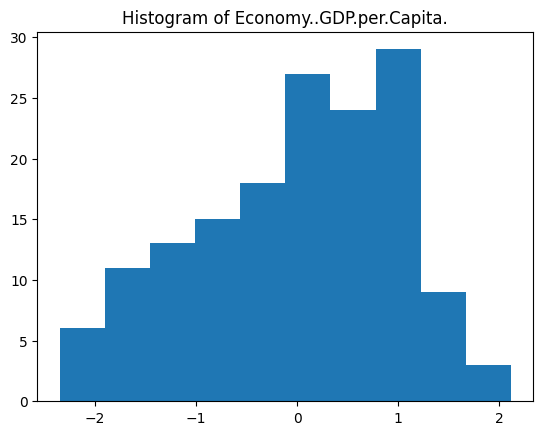

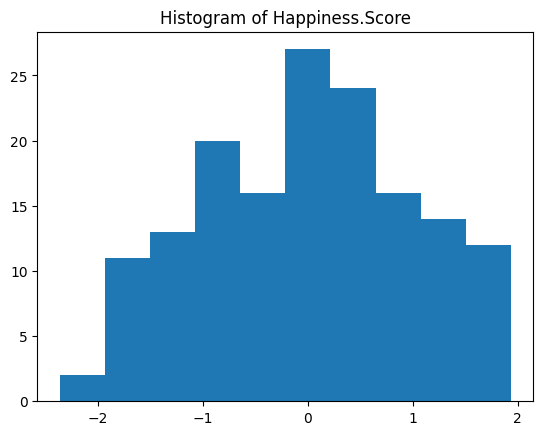

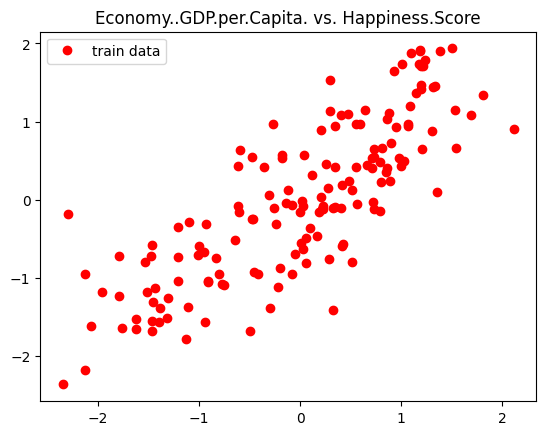

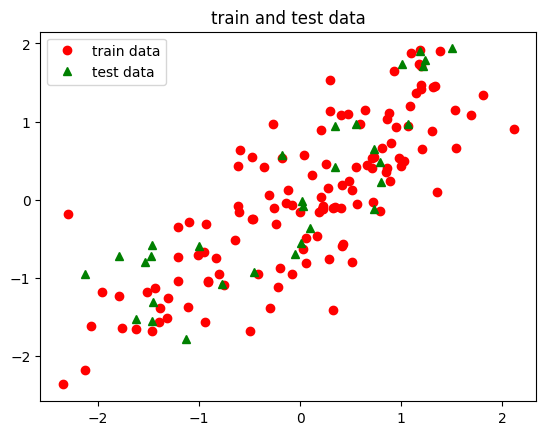

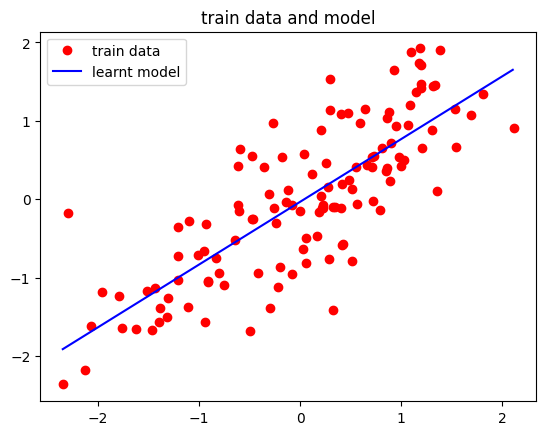

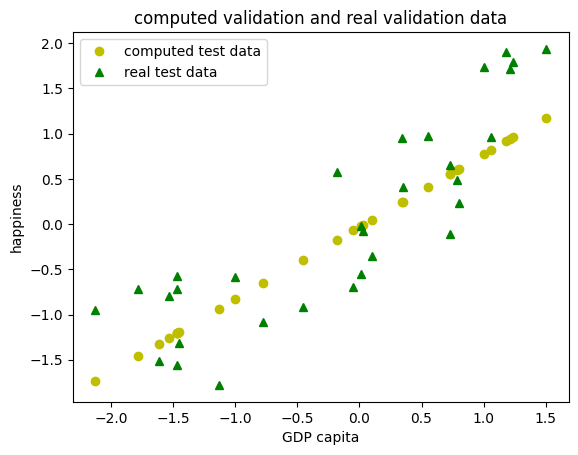

prediction error (manual):  0.32578553890299705
prediction error (tool):  0.32578553890299705


In [ ]:
filePath = "/content/v1_world-happiness-report-2017.csv"

inputVariable = 'Economy..GDP.per.Capita.'
outputVariable = 'Happiness.Score'

makeMyPrediction(filePath, inputVariable, outputVariable)

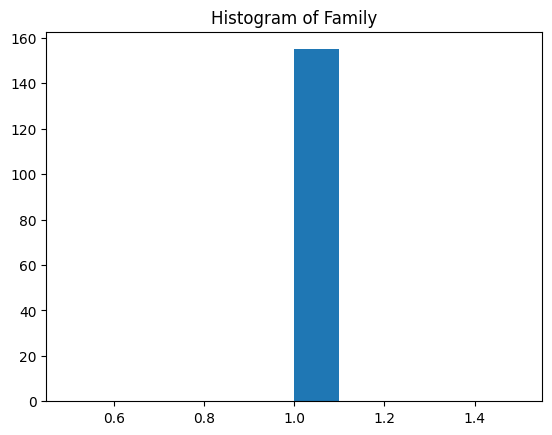

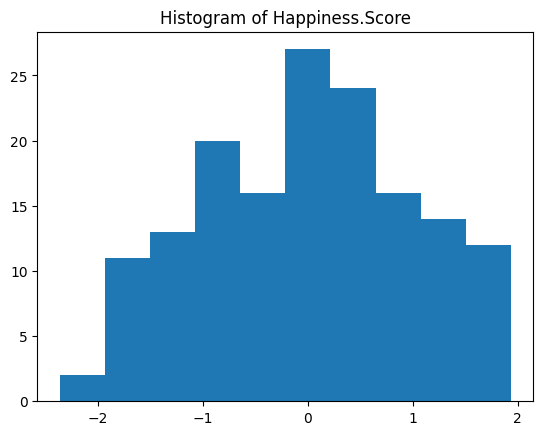

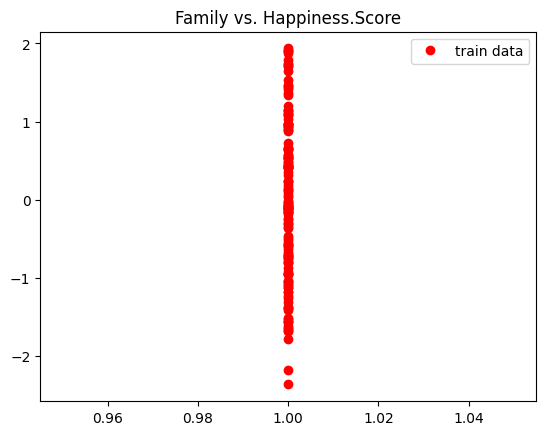

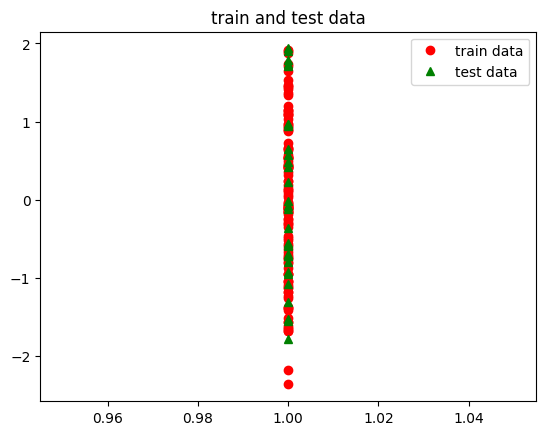

The denominator is very close to zero. Cannot fit the model.


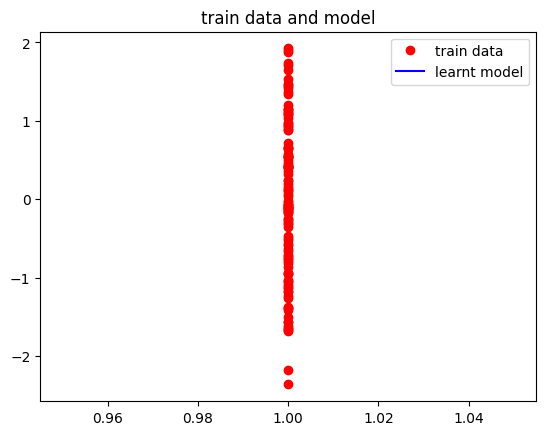

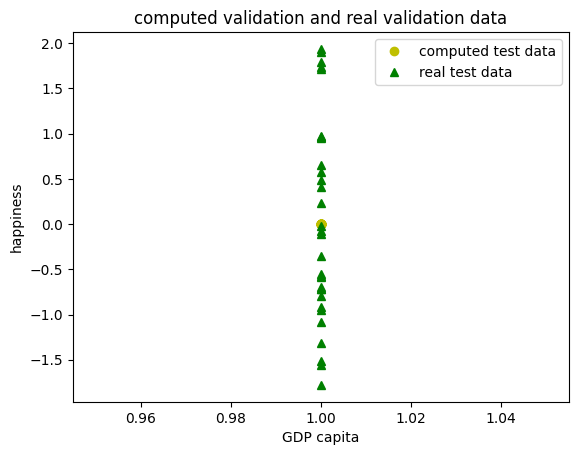

prediction error (manual):  1.1711027958450777
prediction error (tool):  1.1711027958450777


In [ ]:
inputVariable = 'Family'
outputVariable = 'Happiness.Score'

makeMyPrediction(filePath, inputVariable, outputVariable)

### Bivariate Linear Regression

Bivariate linear regression models the relationship between a dependent variable $$ y $$ and two independent variables $$ x_1  and  x_2 $$, using the equation:


$$
y = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2
$$

The coefficients $$ w_1 $$ and $$ w_2 $$ are computed using the least squares method:


$$
w_1 = \frac{n \cdot \sum (x_1 y) - \sum x_1 \cdot \sum y}{n \cdot \sum x_1^2 - (\sum x_1)^2}
$$



$$
w_2 = \frac{n \cdot \sum (x_2 y) - \sum x_2 \cdot \sum y}{n \cdot \sum x_2^2 - (\sum x_2)^2}
$$


The intercept $$ w_0 $$ is calculated as:


$$
w_0 = \frac{\sum y - w_1 \cdot \sum x_1 - w_2 \cdot \sum x_2}{n}
$$


This model helps estimate $$ y $$ based on two predictors and is useful for simple multivariate prediction problems.


In [24]:
class MyLinearBivariateRegression:
    def __init__(self):
        # initialize the model parameters (intercept and coefficients for x1 and x2)
        self.intercept_ = 0.0
        self.coef_ = [0.0, 0.0]

    def fit(self, x, y):
        # compute necessary sums for the formula
        sum_x1 = sum(x_i[0] for x_i in x)
        sum_x2 = sum(x_i[1] for x_i in x)
        sum_y = sum(y)

        n = len(x)  # number of data points

        # compute sums of products for x1*y and x2*y
        sum_x1y = sum(x[i][0] * y[i] for i in range(n))
        sum_x2y = sum(x[i][1] * y[i] for i in range(n))

        # compute sums of squares for x1 and x2
        sum_x1x1 = sum(x[i][0] ** 2 for i in range(n))
        sum_x2x2 = sum(x[i][1] ** 2 for i in range(n))

        # compute coefficients w1 and w2 using the least squares formulas
        self.coef_[0] = (n * sum_x1y - sum_x1 * sum_y) / (n * sum_x1x1 - sum_x1 ** 2)
        self.coef_[1] = (n * sum_x2y - sum_x2 * sum_y) / (n * sum_x2x2 - sum_x2 ** 2)

        # compute the intercept (w0) based on the means
        self.intercept_ = (sum_y - self.coef_[0] * sum_x1 - self.coef_[1] * sum_x2) / n

    def predict(self, x):
        # return predicted values based on the learned model
        if isinstance(x[0], list):
            # input is a list of [x1, x2] pairs
            return [self.intercept_ + self.coef_[0] * val[0] + self.coef_[1] * val[1] for val in x]
        else:
            # fallback: if input is a flat list (not recommended here), treat values as both x1 and x2
            return [self.intercept_ + self.coef_[0] * val + self.coef_[1] * val for val in x]


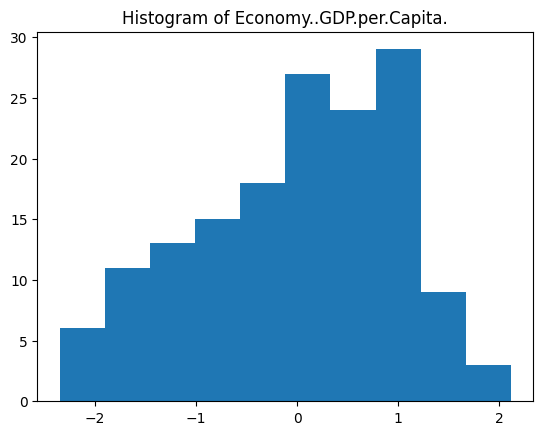

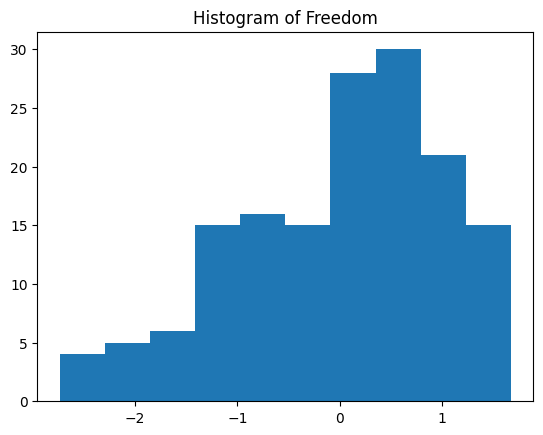

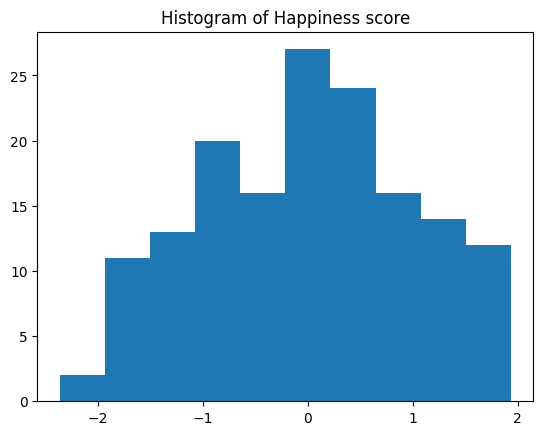

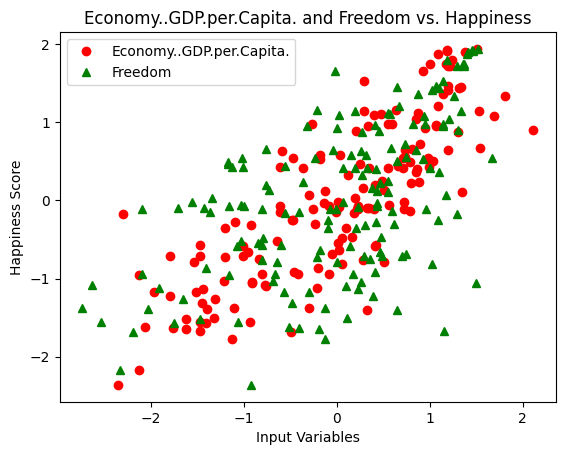

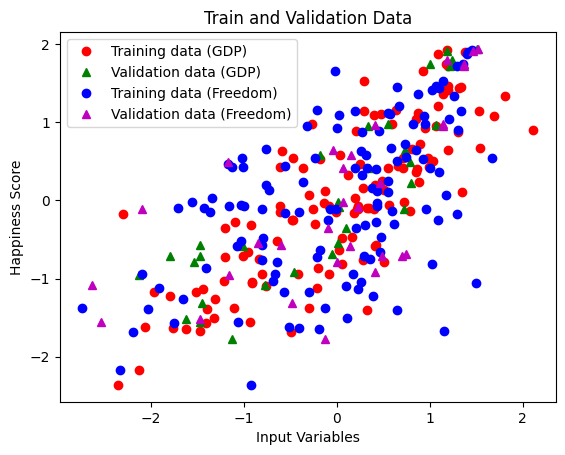

The learnt model: f(x1, x2) =  -0.03251122312159553  +  0.7998814459881276  * x1 +  0.5421725375839325  * x2


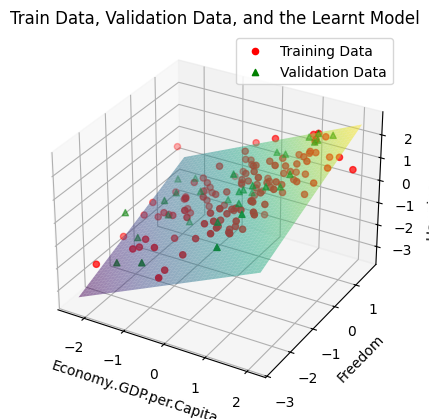

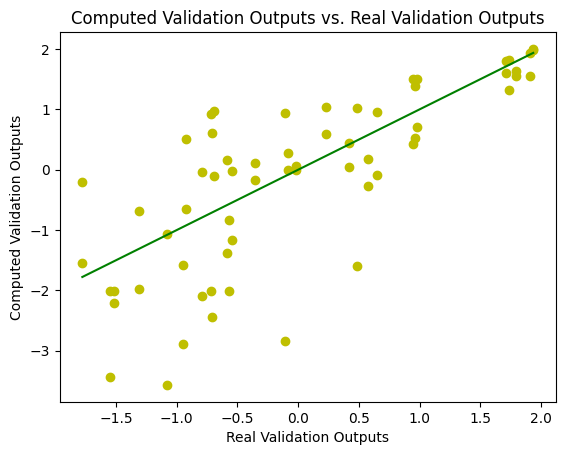

prediction error (manual):  0.6005304398723552
prediction error (tool):  0.6005304398723552


In [ ]:
filePath = "/content/v1_world-happiness-report-2017.csv"

inputVariable1 = 'Economy..GDP.per.Capita.'
inputVariable2 = 'Freedom'
outputVariable = 'Happiness.Score'

outputs, inputs1, inputs2 = loadData(filePath, outputVariable, inputVariable1, inputVariable2)

plotDataHistogram(inputs1, 'Economy..GDP.per.Capita.')
plotDataHistogram(inputs2, 'Freedom')
plotDataHistogram(outputs, 'Happiness score')

# check the liniarity

plt.plot(inputs1, outputs, 'ro', label='Economy..GDP.per.Capita.')
plt.plot(inputs2, outputs, 'g^', label='Freedom')
plt.xlabel('Input Variables')
plt.ylabel('Happiness Score')
plt.title('Economy..GDP.per.Capita. and Freedom vs. Happiness')
plt.legend()
plt.show()

# combine inputs into one matrix
X = np.column_stack((inputs1, inputs2))

# split data into training data (80%) and testing data (20%)
np.random.seed(5)
indexes = np.arange(len(inputs1))

trainSample = np.random.choice(indexes, int(0.8 * len(inputs1)), replace=False)
validationSample = np.array([i for i in indexes if i not in trainSample])

trainInputs = X[trainSample]
trainOutputs = np.array([outputs[i] for i in trainSample])

validationInputs = X[validationSample]
validationOutputs = np.array([outputs[i] for i in validationSample])

# plot train and validation data
plt.plot(trainInputs[:,0], trainOutputs, 'ro', label='Training data (GDP)')
plt.plot(validationInputs[:,0], validationOutputs, 'g^', label='Validation data (GDP)')
plt.plot(trainInputs[:,1], trainOutputs, 'bo', label='Training data (Freedom)')
plt.plot(validationInputs[:,1], validationOutputs, 'm^', label='Validation data (Freedom)')
plt.title('Train and Validation Data')
plt.xlabel('Input Variables')
plt.ylabel('Happiness Score')
plt.legend()
plt.show()

# training step
regressor = MyLinearBivariateRegression()
regressor.fit(trainInputs, trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
print('The learnt model: f(x1, x2) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2')

# prepare synthetic data for plotting the learnt model
noOfPoints = 1000
x1_values = np.linspace(min(inputs1), max(inputs1), noOfPoints)
x2_values = np.linspace(min(inputs2), max(inputs2), noOfPoints)
X1, X2 = np.meshgrid(x1_values, x2_values)
Y = w0 + w1 * X1 + w2 * X2

# plot the model
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(trainInputs[:,0], trainInputs[:,1], trainOutputs, c='r', marker='o', label='Training Data')
ax.scatter(validationInputs[:,0], validationInputs[:,1], validationOutputs, c='g', marker='^', label='Validation Data')
ax.plot_surface(X1, X2, Y, alpha=0.5, cmap='viridis')
ax.set_xlabel('Economy..GDP.per.Capita.')
ax.set_ylabel('Freedom')
ax.set_zlabel('Happiness Score')
plt.title('Train Data, Validation Data, and the Learnt Model')
plt.legend()
plt.show()

# makes predictions for test data
computedValidationOutputs = regressor.predict(validationInputs)

# plot computed outputs vs real outputs
plt.plot(validationOutputs, computedValidationOutputs, 'yo')
plt.plot(validationOutputs, validationOutputs, 'g-')
plt.title('Computed Validation Outputs vs. Real Validation Outputs')
plt.xlabel('Real Validation Outputs')
plt.ylabel('Computed Validation Outputs')
plt.show()

computedValidationOutputs = [
    val[0] if isinstance(val, (list, np.ndarray)) else val
    for val in computedValidationOutputs
]

validationOutputs = [
    val[0] if isinstance(val, (list, np.ndarray)) else val
    for val in validationOutputs
]

computeError(validationOutputs, computedValidationOutputs)